In [1]:
#importing libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import joblib

from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline



In [2]:
#importing data
df = pd.read_csv("..\Datasets\ev_market_2026.csv")
df_copy = df
print(df.head(5))

          brand           model  year      variant  price_usd  \
0    Volkswagen        ID. Buzz  2023  Performance  104880.80   
1        Toyota  bZ Compact SUV  2022      Premium   48217.41   
2  GM/Chevrolet         Bolt EV  2024      Premium   49651.12   
3           Kia     Sportage EV  2024   Long Range   38131.56   
4         Tesla         Model 3  2022   Long Range  144079.87   

   battery_capacity_kwh  range_miles  charging_speed_kw  \
0                 118.7        400.0              234.5   
1                  58.8        219.0              148.1   
2                  58.2        225.0              104.9   
3                 102.5        349.0               66.5   
4                  93.9        314.0              298.5   

   acceleration_0_60_mph  top_speed_mph  ...  body_type  \
0                   3.04          195.0  ...      Truck   
1                   5.77          159.0  ...        SUV   
2                   6.84          148.0  ...        Van   
3                 

In [3]:
df.shape

(2000, 24)

In [4]:
df.columns

Index(['brand', 'model', 'year', 'variant', 'price_usd',
       'battery_capacity_kwh', 'range_miles', 'charging_speed_kw',
       'acceleration_0_60_mph', 'top_speed_mph', 'horsepower', 'torque_nm',
       'drive_type', 'seating_capacity', 'body_type', 'cargo_volume_cubic_ft',
       'weight_kg', 'safety_rating', 'autopilot_level', 'country_of_origin',
       'market_segment', 'annual_sales_units', 'customer_rating',
       'warranty_years'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand                  2000 non-null   object 
 1   model                  2000 non-null   object 
 2   year                   2000 non-null   int64  
 3   variant                2000 non-null   object 
 4   price_usd              2000 non-null   float64
 5   battery_capacity_kwh   2000 non-null   float64
 6   range_miles            2000 non-null   float64
 7   charging_speed_kw      2000 non-null   float64
 8   acceleration_0_60_mph  2000 non-null   float64
 9   top_speed_mph          2000 non-null   float64
 10  horsepower             2000 non-null   float64
 11  torque_nm              2000 non-null   float64
 12  drive_type             2000 non-null   object 
 13  seating_capacity       2000 non-null   int64  
 14  body_type              2000 non-null   object 
 15  carg

In [6]:
(df.isnull().sum()/len(df))*100

brand                    0.0
model                    0.0
year                     0.0
variant                  0.0
price_usd                0.0
battery_capacity_kwh     0.0
range_miles              0.0
charging_speed_kw        0.0
acceleration_0_60_mph    0.0
top_speed_mph            0.0
horsepower               0.0
torque_nm                0.0
drive_type               0.0
seating_capacity         0.0
body_type                0.0
cargo_volume_cubic_ft    0.0
weight_kg                0.0
safety_rating            0.0
autopilot_level          0.0
country_of_origin        0.0
market_segment           0.0
annual_sales_units       0.0
customer_rating          0.0
warranty_years           0.0
dtype: float64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

brand                     object
model                     object
year                       int64
variant                   object
price_usd                float64
battery_capacity_kwh     float64
range_miles              float64
charging_speed_kw        float64
acceleration_0_60_mph    float64
top_speed_mph            float64
horsepower               float64
torque_nm                float64
drive_type                object
seating_capacity           int64
body_type                 object
cargo_volume_cubic_ft    float64
weight_kg                float64
safety_rating              int64
autopilot_level            int64
country_of_origin         object
market_segment            object
annual_sales_units         int64
customer_rating          float64
warranty_years             int64
dtype: object

In [9]:
df.describe()

,year,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,horsepower,torque_nm,seating_capacity,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,annual_sales_units,customer_rating,warranty_years
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2024.028500,78873.907150,74.662800,261.825500,155.206300,5.630635,164.884500,665.744000,601.311500,5.747000,46.105850,1886.164500,4.377000,1.124500,129653.592000,3.572045,4.579000
std,1.410561,35296.621782,20.082879,71.028238,80.982301,1.417733,20.781244,267.124838,238.706686,1.045245,19.850264,383.772906,0.661127,0.919469,105775.154465,0.270398,1.218812
min,2020.000000,16394.330000,40.000000,150.000000,50.000000,2.500000,118.000000,150.000000,200.000000,2.000000,15.000000,1500.000000,3.000000,0.000000,656.000000,3.000000,3.000000
25%,2023.000000,52325.920000,58.475000,204.000000,90.975000,4.620000,148.000000,442.750000,391.750000,5.000000,28.175000,1570.000000,4.000000,0.000000,44296.500000,3.380000,4.000000
50%,2024.000000,73013.015000,75.100000,261.000000,132.100000,5.670000,165.000000,683.000000,615.500000,5.000000,41.250000,1740.500000,4.000000,1.000000,111188.000000,3.560000,4.000000
75%,2025.000000,99780.157500,87.550000,310.000000,217.300000,6.770000,181.000000,939.250000,845.000000,7.000000,64.700000,2149.500000,5.000000,2.000000,202496.750000,3.750000,5.000000
max,2026.000000,269775.200000,119.900000,447.000000,349.900000,8.000000,200.000000,1000.000000,988.000000,7.000000,80.000000,3000.000000,5.000000,3.000000,499717.000000,4.510000,8.000000


In [10]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

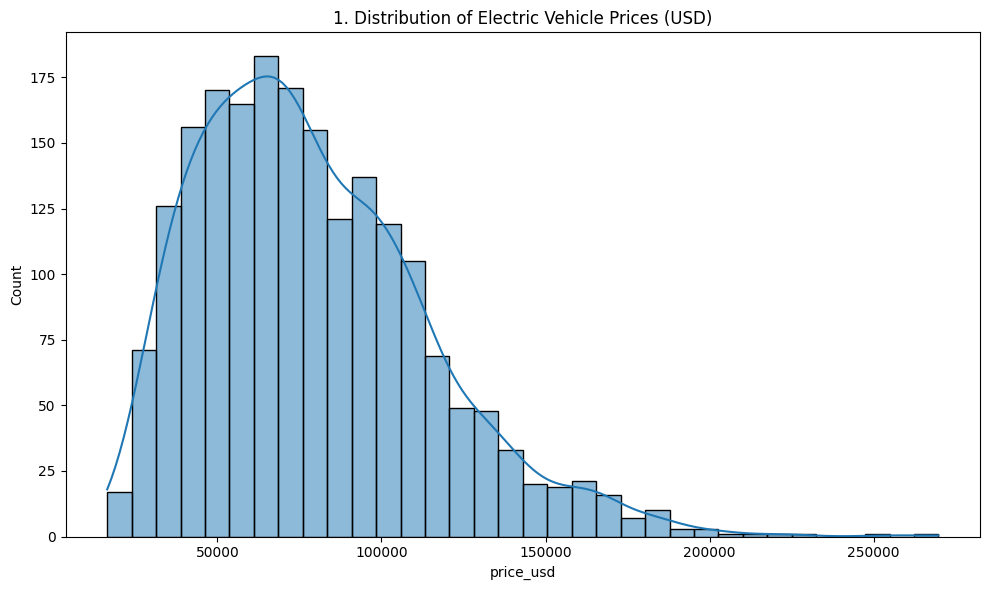

In [11]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['price_usd'], kde=True)
plt.title(f'{plot_no}. Distribution of Electric Vehicle Prices (USD)')
show_fig()
plot_no += 1

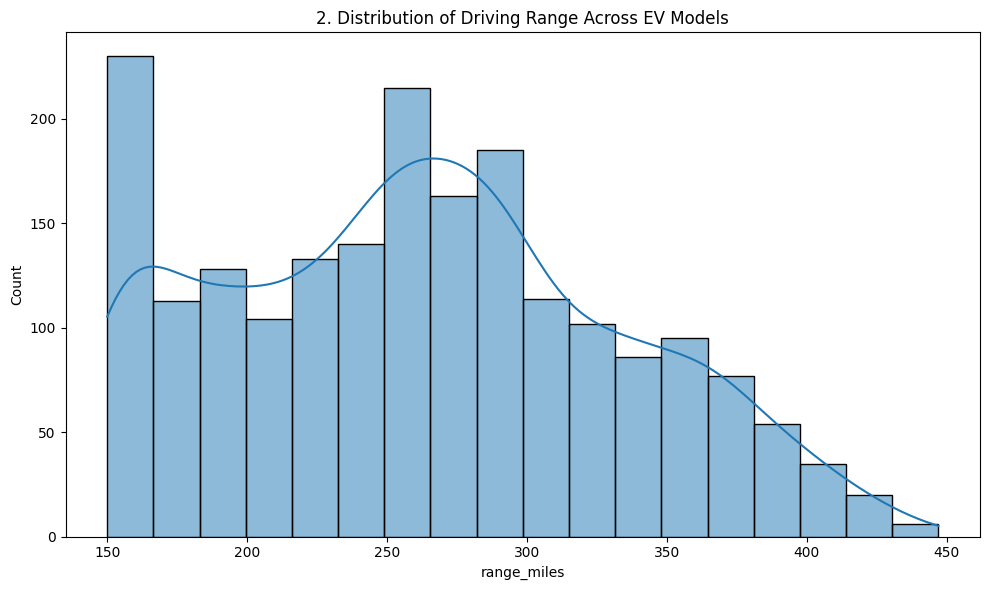

In [12]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['range_miles'], kde=True)
plt.title(f'{plot_no}. Distribution of Driving Range Across EV Models')
show_fig()
plot_no += 1

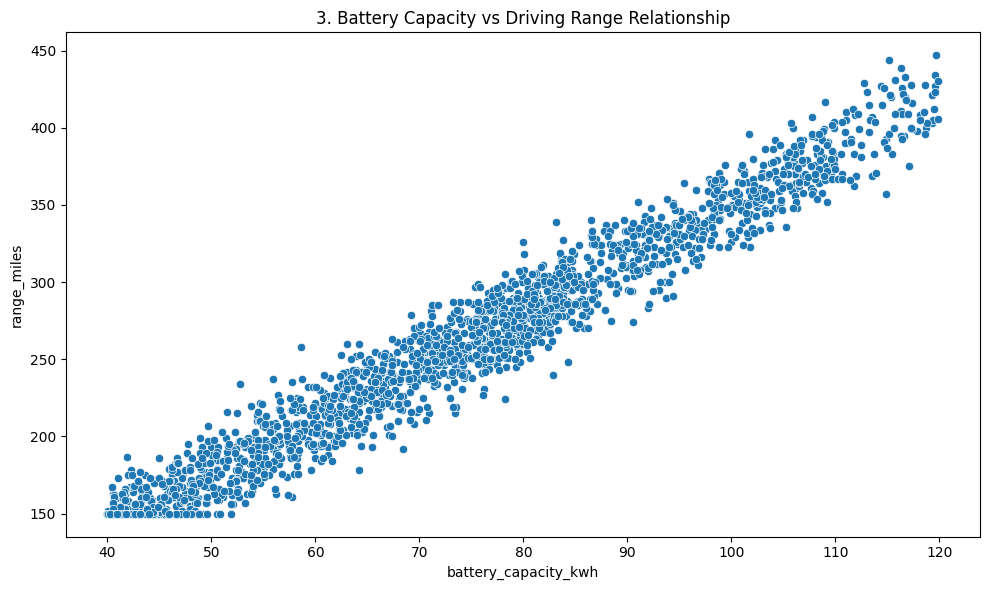

In [13]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='battery_capacity_kwh', y='range_miles', data=df)
plt.title(f'{plot_no}. Battery Capacity vs Driving Range Relationship')
show_fig()
plot_no += 1

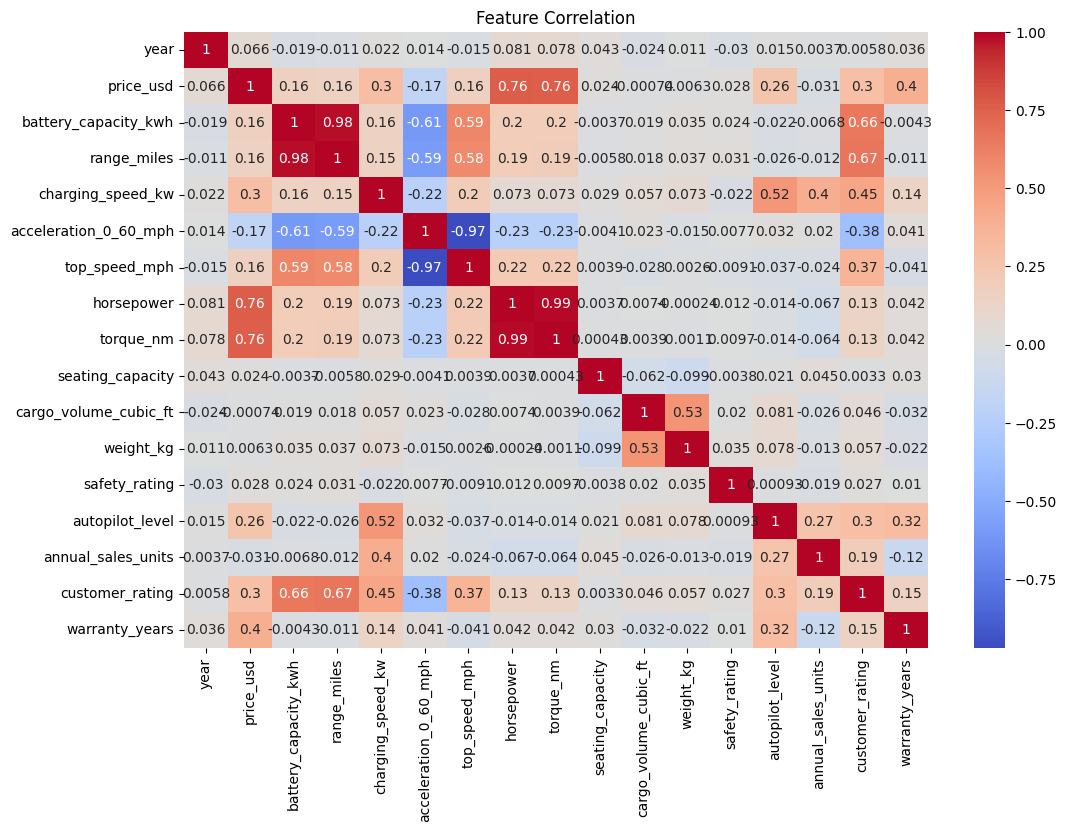

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()


Customer Rating Prediction

In [15]:
df.columns

Index(['brand', 'model', 'year', 'variant', 'price_usd',
       'battery_capacity_kwh', 'range_miles', 'charging_speed_kw',
       'acceleration_0_60_mph', 'top_speed_mph', 'horsepower', 'torque_nm',
       'drive_type', 'seating_capacity', 'body_type', 'cargo_volume_cubic_ft',
       'weight_kg', 'safety_rating', 'autopilot_level', 'country_of_origin',
       'market_segment', 'annual_sales_units', 'customer_rating',
       'warranty_years'],
      dtype='object')

See Target Distribution

In [16]:
#Remove unwanted Columns
cols_to_drop = [
    'acceleration_0_60_mph',
    'torque_nm',
    'variant',
    'safety_rating',
    'weight_kg',
    'cargo_volume_cubic_ft',
    'seating_capacity',
    'year',
    'annual_sales_units',
    'top_speed_mph',
    'model',
    'autopilot_level',
    'warranty_years',
    'country_of_origin',
    'body_type',
    'customer_rating'
]

df = df.drop(columns=cols_to_drop)

#Define X(features) and y(target)
X = df.drop(columns="price_usd")
y = df["price_usd"]

#Do test-train split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=17
)

#Now we want to do scaling for numerical columns and encodeing for categorical
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns


#Numerical sacling Pipeline 
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

#Categorical encoding pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )
])

#Column Transformer
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

#Full Pipline with Logistic regression
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

#training model
model_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [17]:
# Predictions
pred = model_pipeline.predict(X_test)

In [18]:
from sklearn.metrics import mean_absolute_error

print("MAE:", mean_absolute_error(y_test, pred))

MAE: 4082.5849612499983


In [19]:
import numpy as np
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE:", rmse)

RMSE: 7911.482884304655


In [20]:
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_test, pred))

R2 Score: 0.9504508355181157


In [21]:
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_test, pred))

R2 Score: 0.9504508355181157


In [22]:
X

,brand,battery_capacity_kwh,range_miles,charging_speed_kw,horsepower,drive_type,market_segment
0,Volkswagen,118.7,400.0,234.5,1000.0,AWD,Luxury
1,Toyota,58.8,219.0,148.1,381.0,FWD,Mid-range
2,GM/Chevrolet,58.2,225.0,104.9,588.0,AWD,Mid-range
3,Kia,102.5,349.0,66.5,310.0,AWD,Mid-range
4,Tesla,93.9,314.0,298.5,1000.0,RWD,Luxury
...,...,...,...,...,...,...,...
1995,BMW,102.1,360.0,92.0,1000.0,FWD,Luxury
1996,Toyota,110.6,367.0,236.3,783.0,AWD,Premium
1997,Tesla,90.6,325.0,325.6,351.0,RWD,Mid-range
1998,Tesla,70.7,248.0,330.7,1000.0,RWD,Luxury


### SelectKBest

SelectKBest selects the K most statistically relevant features.

In [23]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import SelectKBest, f_regression
kbest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=f_regression,  k=10)),
    ("model", RandomForestRegressor(random_state=42))
])

In [24]:
kbest_pipeline.fit(X_train, y_train)

pred_kbest = kbest_pipeline.predict(X_test)

In [25]:
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_test, pred_kbest))

R2 Score: 0.9151981070823668


In [26]:


model_xgboost = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

model_xgboost.fit(X_train, y_train)
xgboost_pred = model_xgboost.predict(X_test)

In [27]:
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_test, xgboost_pred))

R2 Score: 0.9549224971148315


In [28]:
print("y_test min/max:", y_test.min(), y_test.max())
print("pred min/max:", pred.min(), pred.max())

y_test min/max: 20788.8 254017.08
pred min/max: 18899.8564 189559.54580000002


In [29]:
import numpy as np

print("MAE:", np.mean(np.abs(y_test - pred)))

MAE: 4082.5849612499983


random Forest:

Target range:
y_test: 20,788 → 254,017
Predictions:
pred: 19,897 → 186,119
MAE:≈ 4087.98

R²:≈ 0.955

✔ Model is valid
✔ Performance is strong
✔ No signs of leakage
✔ Slight underprediction of luxury segment (normal)

Save the model

In [30]:

joblib.dump(model_xgboost, "ev_price_model.pkl")

['ev_price_model.pkl']

## Second Model for Sales Prediction

Model for predicting Sales in coming years

In [31]:
# -----------------------------
# Drop only truly irrelevant columns
# -----------------------------
cols_to_drop = [
    'acceleration_0_60_mph',
    'torque_nm',
    'variant',
    'safety_rating',
    'weight_kg',
    'cargo_volume_cubic_ft',
    'seating_capacity',
    'top_speed_mph',
    'year',
    'autopilot_level',
    'warranty_years',
    'body_type',
    'customer_rating',
    'battery_capacity_kwh',
    'charging_speed_kw',
    'market_segment'
]

df_model = df_copy.drop(columns=cols_to_drop)

# -----------------------------
# Features & target
# -----------------------------
X = df_model.drop(columns=["annual_sales_units"])
y = df_model["annual_sales_units"]


#Do test-train split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=17
)

#Now we want to do scaling for numerical columns and encodeing for categorical
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns


#Numerical sacling Pipeline 
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

#Categorical encoding pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )
])

#Column Transformer
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

#Full Pipline with Logistic regression
model_sales = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

#training model
model_sales.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [32]:
model_sales_pred = model_sales.predict(X_test)
print("R2 Score:", r2_score(y_test, model_sales_pred))

R2 Score: 0.8825547086245514


Trying Xgboost 

In [33]:

# =============================
# Train-test split
# =============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =============================
# Column types
# =============================
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

# =============================
# Preprocessor
# =============================
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

# =============================
# XGBoost Model
# =============================
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

# =============================
# Pipeline
# =============================
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])


In [34]:
# =============================
# Train
# =============================
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [35]:
# =============================
# Predict
# =============================
pred = pipeline.predict(X_test)

# =============================
# Evaluation
# =============================
print("R2 Score:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE:", rmse)

R2 Score: 0.9022782444953918
MAE: 26208.955078125
RMSE: 33215.34488756665


R2 Score of RandomForestRegressor is good.
but MAE and RMSE is varying more, the next step of project would be to see how can we reduce MAE and RMSE.

Actually for price prediction model, i already played with featured and reduced these MAE and RMSE values significently, same will be done for this Sales model.

Saving the sales model

In [36]:

joblib.dump(model_sales, "ev_sales_model.pkl")

['ev_sales_model.pkl']